In [1]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split

print("TensorFlow:", tf.__version__)
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

2025-11-28 05:22:21.962431: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764287541.978817   76728 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764287541.983701   76728 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1764287541.998158   76728 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1764287541.998181   76728 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1764287541.998183   76728 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
Num GPUs Available:  1


In [ ]:
PATH = "dataset/"
df = pd.read_csv(PATH + "train.csv")
pivot_df = df.pivot_table(index='image_path', columns='target_name', values='target').reset_index()

target_cols = ['Dry_Green_g', 'Dry_Dead_g', 'Dry_Clover_g', 'GDM_g', 'Dry_Total_g']
pivot_df = pivot_df[['image_path'] + target_cols]

train_df, val_df = train_test_split(pivot_df, test_size=0.15, random_state=42)

In [ ]:
# 4. Create TensorFlow Dataset
IMG_SIZE = 900
BATCH_SIZE = 8

def load_image(path):
    # Expand on this function MORE (image pre-processing here)
    img = tf.io.read_file(PATH + "/" + path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32) / 255.0  
    return img


In [4]:
def create_dataset(dataframe, batch_size=BATCH_SIZE, shuffle=False):
    image_paths = dataframe['image_path'].values # ONLY the path of every image 
    
    targets = dataframe[target_cols].values.astype(np.float32)
    ds = tf.data.Dataset.from_tensor_slices((image_paths, targets))

    def map_func(path, target):
        return load_image(path), target
    
    ds = ds.map(map_func, num_parallel_calls=tf.data.AUTOTUNE)
    
    if shuffle:
        ds = ds.shuffle(buffer_size=1000)
        
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = create_dataset(train_df, shuffle=True)
val_ds = create_dataset(val_df, shuffle=False)



I0000 00:00:1764287545.146872   76728 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5438 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


2025-11-28 05:22:26.817206: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


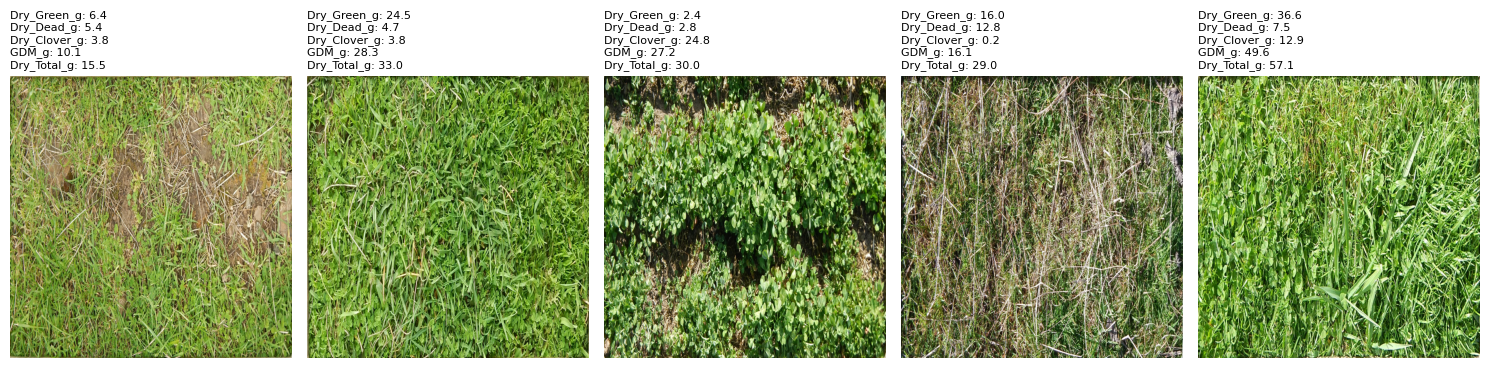

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

for images, targets in train_ds.take(1):
    for i in range(5):
        ax = plt.subplot(1, 5, i + 1)
        plt.imshow(images[i].numpy())
        
        # Create a string for the targets
        t = targets[i].numpy()
        title_str = "\n".join([f"{n}: {v:.1f}" for n, v in zip(target_cols, t)])
        
        plt.title(title_str, fontsize=8, loc='left')
        plt.axis("off")
plt.tight_layout()
plt.show()

## BUILDING THE MODEL NOW

In [6]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Conv2D, SeparableConv2D, BatchNormalization, ReLU, Add,
    GlobalAveragePooling2D, Dense, Dropout, Input,
    Multiply, Reshape
)
from tensorflow.keras.models import Model


# ------------------------------------------------------------
# BASIC RESNET BLOCK (unchanged)
# ------------------------------------------------------------
def resnet_block(x, filters, stride=1):
    shortcut = x

    y = Conv2D(filters, 3, strides=stride, padding="same", use_bias=False)(x)
    y = BatchNormalization()(y)
    y = ReLU()(y)

    y = Conv2D(filters, 3, padding="same", use_bias=False)(y)
    y = BatchNormalization()(y)

    if stride != 1 or x.shape[-1] != filters:
        shortcut = Conv2D(filters, 1, strides=stride, padding="same", use_bias=False)(shortcut)
        shortcut = BatchNormalization()(shortcut)

    out = Add()([y, shortcut])
    out = ReLU()(out)
    return out


# ------------------------------------------------------------
# LITE BLOCK (ONLY for Stage 0 + Stage 1)
# ------------------------------------------------------------
def lite_block(x, filters, stride=1):
    shortcut = x

    y = SeparableConv2D(filters, 3, strides=stride, padding="same", use_bias=False)(x)
    y = BatchNormalization()(y)
    y = ReLU()(y)

    y = SeparableConv2D(filters, 3, padding="same", use_bias=False)(y)
    y = BatchNormalization()(y)

    if stride != 1 or x.shape[-1] != filters:
        shortcut = Conv2D(filters, 1, strides=stride, padding="same", use_bias=False)(shortcut)
        shortcut = BatchNormalization()(shortcut)

    out = Add()([y, shortcut])
    out = ReLU()(out)
    return out


# ------------------------------------------------------------
# Squeeze–Excitation (unchanged)
# ------------------------------------------------------------
def squeeze_excitation(x, reduction=16):
    filters = x.shape[-1]
    se = GlobalAveragePooling2D()(x)
    se = Dense(filters // reduction, activation="relu")(se)
    se = Dense(filters, activation="sigmoid")(se)
    se = Reshape((1, 1, filters))(se)
    return Multiply()([x, se])


# ------------------------------------------------------------
# FINAL MODEL (minimal VRAM fix)
# ------------------------------------------------------------
def build_improved_model(img_size=512):
    inputs = Input(shape=(img_size, img_size, 3), name="image_input")

    # Stem
    x = Conv2D(32, 3, strides=2, padding="same", use_bias=False)(inputs)
    x = BatchNormalization()(x)
    x = ReLU()(x)    # -> 500×500×32 if input=1000

    # Stage 0 (LITE)
    x = lite_block(x, 32, stride=1)

    # Stage 1 (LITE)
    x = lite_block(x, 64, stride=1)
    x = lite_block(x, 64, stride=2)

    # Stage 2 (FULL)
    x = resnet_block(x, 128, stride=1)
    x = resnet_block(x, 128, stride=2)

    # Stage 3 (FULL)
    x = resnet_block(x, 256, stride=1)
    x = resnet_block(x, 256, stride=2)

    # Stage 4 (FULL)
    x = resnet_block(x, 512, stride=1)
    x = resnet_block(x, 512, stride=2)

    # SE
    x = squeeze_excitation(x)

    # Head
    x = GlobalAveragePooling2D()(x)
    x = Dense(512, activation="relu")(x)
    x = Dropout(0.25)(x)
    x = Dense(256, activation="relu")(x)
    x = Dropout(0.15)(x)
    x = Dense(128, activation="relu")(x)

    outputs = Dense(5)(x)

    return Model(inputs, outputs)


model = build_improved_model(IMG_SIZE)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 900, 900,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 450, 450,  │        864 │ image_input[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 450, 450,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 450, 450,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d    │ (None, 450, 450,  │      1,312 │ re_lu[0][0]       │
│ (SeparableConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 450, 450,  │        128 │ separable_conv2d… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 450, 450,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_1  │ (None, 450, 450,  │      1,312 │ re_lu_1[0][0]     │
│ (SeparableConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 450, 450,  │        128 │ separable_conv2d… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 450, 450,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │ re_lu[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 450, 450,  │          0 │ add[0][0]         │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_2  │ (None, 450, 450,  │      2,336 │ re_lu_2[0][0]     │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 450, 450,  │        256 │ separable_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 450, 450,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_3  │ (None, 450, 450,  │      4,672 │ re_lu_3[0][0]     │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 450, 450,  │      2,048 │ re_lu_2[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 450, 450,  │        256 │ separable_conv2d

 Total params: 11,864,357 (45.26 MB)

 Trainable params: 11,852,645 (45.21 MB)

 Non-trainable params: 11,712 (45.75 KB)

In [7]:
# model arch 
from tensorflow.keras.utils import plot_model
from IPython.display import Image, display

# plot_model(model, to_file="/home/vector/project/CSIRO---Image2Biomass-Prediction/model.png", show_shapes=True, show_layer_names=True)

# Image is wayy too long, working on notebook becomes difficult

# we will assign weights to the output parameters

In [8]:
import tensorflow.keras.backend as K

def weighted_r2(y_true, y_pred):
    # Weights for the 5 biomass components
    # Dry_Green_g, Dry_Dead_g, Dry_Clover_g, GDM_g, Dry_Total_g
    weights = tf.constant([0.1, 0.1, 0.1, 0.2, 0.5], dtype=tf.float32)
    
    # Total Sum of Squares (TSS)
    mean_y_true = K.mean(y_true, axis=0)
    tss = K.sum(K.square(y_true - mean_y_true), axis=0)
    
    # Residual Sum of Squares (RSS)
    rss = K.sum(K.square(y_true - y_pred), axis=0)
    
    # R2 for each component: 1 - (RSS / (TSS + epsilon))
    # Adding epsilon to avoid division by zero
    r2_scores = 1 - (rss / (tss + K.epsilon()))
    
    # Weighted Average R2
    weighted_r2_score = K.sum(r2_scores * weights)
    
    return weighted_r2_score



def r2_metric(y_true, y_pred):
    ss_res = tf.reduce_sum(tf.square(y_true - y_pred))
    ss_tot = tf.reduce_sum(tf.square(y_true - tf.reduce_mean(y_true)))
    return 1 - ss_res / (ss_tot + 1e-7)

def mae_0(y_true, y_pred): return tf.reduce_mean(tf.abs(y_true[:,0] - y_pred[:,0]))
def mae_1(y_true, y_pred): return tf.reduce_mean(tf.abs(y_true[:,1] - y_pred[:,1]))
def mae_2(y_true, y_pred): return tf.reduce_mean(tf.abs(y_true[:,2] - y_pred[:,2]))
def mae_3(y_true, y_pred): return tf.reduce_mean(tf.abs(y_true[:,3] - y_pred[:,3]))
def mae_4(y_true, y_pred): return tf.reduce_mean(tf.abs(y_true[:,4] - y_pred[:,4]))


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss=tf.keras.losses.Huber(delta=1.0),

    metrics=[
        'mae',        # overall MAE
        r2_metric,    # model quality metric
        mae_0,        
        mae_1,        
        mae_2,        
        mae_3,        
        mae_4,        
        weighted_r2
    ]
)


In [10]:
# Callbacks
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    'best_model.keras', 
    monitor='val_weighted_r2', 
    mode='max', 
    save_best_only=True, 
    verbose=1
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_weighted_r2', 
    mode='max', 
    patience=10, 
    restore_best_weights=True,
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_weighted_r2', 
    mode='max', 
    factor=0.5, 
    patience=5, 
    min_lr=1e-6,
    verbose=1
)

# Train
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=1,
    callbacks=[checkpoint, reduce_lr]
)


I0000 00:00:1764287557.663010   76945 service.cc:152] XLA service 0x7f59b400bb70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1764287557.663034   76945 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
2025-11-28 05:22:37.936200: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1764287559.372951   76945 cuda_dnn.cc:529] Loaded cuDNN version 91002
2025-11-28 05:22:40.481035: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_6713', 40 bytes spill stores, 40 bytes spill loads

2025-11-28 05:22:40.803397: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusio

ResourceExhaustedError: Graph execution error:

Detected at node StatefulPartitionedCall defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/home/vector/anaconda3/envs/gpu/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>

  File "/home/vector/anaconda3/envs/gpu/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance

  File "/home/vector/anaconda3/envs/gpu/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 739, in start

  File "/home/vector/anaconda3/envs/gpu/lib/python3.12/site-packages/tornado/platform/asyncio.py", line 211, in start

  File "/home/vector/anaconda3/envs/gpu/lib/python3.12/asyncio/base_events.py", line 645, in run_forever

  File "/home/vector/anaconda3/envs/gpu/lib/python3.12/asyncio/base_events.py", line 1999, in _run_once

  File "/home/vector/anaconda3/envs/gpu/lib/python3.12/asyncio/events.py", 

In [ ]:
import matplotlib.pyplot as plt

def plot_history(history):
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    mae = history.history['mae']
    val_mae = history.history['val_mae']
    r2 = history.history['weighted_r2']
    val_r2 = history.history['val_weighted_r2']
    
    epochs = range(1, len(loss) + 1)
    
    plt.figure(figsize=(18, 5))
    
    # Plot Loss
    plt.subplot(1, 3, 1)
    plt.plot(epochs, loss, 'bo-', label='Training Loss')
    plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
    plt.title('Training and Validation Loss (MSE)')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    
    # Plot MAE
    plt.subplot(1, 3, 2)
    plt.plot(epochs, mae, 'bo-', label='Training MAE')
    plt.plot(epochs, val_mae, 'ro-', label='Validation MAE')
    plt.title('Training and Validation MAE')
    plt.xlabel('Epochs')
    plt.ylabel('MAE')
    plt.legend()
    
    # Plot Weighted R2
    plt.subplot(1, 3, 3)
    plt.plot(epochs, r2, 'bo-', label='Training Weighted R2')
    plt.plot(epochs, val_r2, 'ro-', label='Validation Weighted R2')
    plt.title('Training and Validation Weighted R2')
    plt.xlabel('Epochs')
    plt.ylabel('Weighted R2')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

plot_history(history)


In [ ]:
model.save("model7_v2.h5")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def evaluate_and_visualize(model, val_ds, num_samples=5):
    # 1. Get all predictions and true values
    all_images = []
    all_targets = []
    all_preds = []
    
    print("Generating predictions for validation set...")
    # Unbatch the dataset to process all samples
    for images, targets in val_ds:
        preds = model.predict(images, verbose=0)
        all_images.append(images.numpy())
        all_targets.append(targets.numpy())
        all_preds.append(preds)
        
    # Concatenate batches
    all_images = np.concatenate(all_images, axis=0)
    all_targets = np.concatenate(all_targets, axis=0)
    all_preds = np.concatenate(all_preds, axis=0)
    
    # 2. Calculate Overall Weighted R2
    weights = np.array([0.1, 0.1, 0.1, 0.2, 0.5])
    
    mean_true = np.mean(all_targets, axis=0)
    tss = np.sum((all_targets - mean_true)**2, axis=0)
    rss = np.sum((all_targets - all_preds)**2, axis=0)
    
    # Avoid division by zero
    r2_scores = 1 - (rss / (tss + 1e-7))
    weighted_r2 = np.sum(r2_scores * weights)
    
    print(f"\nOverall Weighted R2 Score: {weighted_r2:.4f}")
    print(f"Component R2 Scores:")
    target_names = ['Dry_Green_g', 'Dry_Dead_g', 'Dry_Clover_g', 'GDM_g', 'Dry_Total_g']
    for name, score in zip(target_names, r2_scores):
        print(f"  {name:<15}: {score:.4f}")
        
    # 3. Visualize Samples
    print(f"\nVisualizing {num_samples} random samples...")
    indices = np.random.choice(len(all_images), num_samples, replace=False)
    
    for idx in indices:
        img = all_images[idx]
        true = all_targets[idx]
        pred = all_preds[idx]
        
        plt.figure(figsize=(12, 4))
        
        # Image
        plt.subplot(1, 2, 1)
        plt.imshow(img)
        plt.axis('off')
        plt.title("Input Image")
        
        # Table of values
        plt.subplot(1, 2, 2)
        plt.axis('off')
        
        # Header
        text_str = f"{'Component':<15} | {'True':>6} | {'Pred':>6} | {'Diff':>6}\n"
        text_str += "-"*45 + "\n"
        
        # Rows
        for i, name in enumerate(target_names):
            diff = pred[i] - true[i]
            text_str += f"{name:<15} | {true[i]:6.1f} | {pred[i]:6.1f} | {diff:6.1f}\n"
            
        plt.text(0, 0.5, text_str, fontsize=12, family='monospace', va='center')
        plt.tight_layout()
        plt.show()

# Run evaluation
evaluate_and_visualize(model, val_ds)


In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
import os

def generate_submission(model):
    print("Loading test data...")
    test_df = pd.read_csv("dataset/test.csv")
    
    # Get unique images to predict on
    unique_images = test_df['image_path'].unique()
    print(f"Found {len(unique_images)} unique test images.")
    
    # Create Dataset
    def load_image(path):
        # Check if path exists
        full_path = "dataset/" + path
        img = tf.io.read_file(full_path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
        img = tf.cast(img, tf.float32) / 255.0
        return img

    test_ds = tf.data.Dataset.from_tensor_slices(unique_images)
    test_ds = test_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    
    print("Predicting...")
    # Predict
    predictions = model.predict(test_ds, verbose=1)
    
    # Map predictions to image paths
    # predictions shape: (N_images, 5)
    # Target order: ['Dry_Green_g', 'Dry_Dead_g', 'Dry_Clover_g', 'GDM_g', 'Dry_Total_g']
    target_cols = ['Dry_Green_g', 'Dry_Dead_g', 'Dry_Clover_g', 'GDM_g', 'Dry_Total_g']
    
    # Create a lookup dictionary: image_path -> {target_name: value}
    pred_dict = {}
    for img_path, pred_row in zip(unique_images, predictions):
        pred_dict[img_path] = {col: val for col, val in zip(target_cols, pred_row)}
        
    print("Formatting submission...")
    # Create submission rows
    submission_rows = []
    for index, row in test_df.iterrows():
        img_path = row['image_path']
        target_name = row['target_name']
        sample_id = row['sample_id']
        
        # Get prediction
        if img_path in pred_dict:
            pred_value = pred_dict[img_path][target_name]
        else:
            # Fallback if something went wrong (shouldn't happen)
            pred_value = 0.0
        
        # Ensure non-negative (biomass can't be negative)
        pred_value = max(0.0, pred_value)
        
        submission_rows.append({'sample_id': sample_id, 'target': pred_value})
        
    submission_df = pd.DataFrame(submission_rows)
    
    # Save to CSV
    output_file = "submission.csv"
    submission_df.to_csv(output_file, index=False)
    print(f"Saved submission to {output_file}")
    
    # Print the content for user to copy if needed
    print("\n" + "="*20 + " SUBMISSION CSV CONTENT " + "="*20)
    print(submission_df.to_csv(index=False))
    print("="*64)

# Run generation
generate_submission(model)
